# Stock Prediction Project

This notebook performs data analysis, visualization, statistical testing, and machine learning on stock data.

##  1. Import Libraries

We import all required libraries for data handling, visualization, machine learning, and statistical testing.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from scipy import stats
import seaborn as sns
import yfinance as yf

##  2. Load Dataset

Load stock dataset from a CSV file. Replace 'stock_data.csv' with your dataset.

In [7]:
ticker = ['ADANIENT.NS',]
df = yf.download(ticker, period="1y")
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,ADANIENT.NS,ADANIENT.NS,ADANIENT.NS,ADANIENT.NS,ADANIENT.NS
Date,,,,,
2025-04-15,2417.001709,2438.790956,2357.831092,2373.823164,1145125
2025-04-16,2414.403076,2426.796834,2381.719085,2398.810709,889949
2025-04-17,2416.901855,2447.386742,2390.814691,2416.801807,1054797
2025-04-21,2441.489502,2463.678452,2394.312940,2424.897874,782559
2025-04-22,2444.288330,2482.169454,2439.790560,2457.681593,766567


##  3. Data Cleaning

Handle missing values and format date column if present.

In [8]:
df.dropna(inplace=True)
df.columns = df.columns.droplevel(1)

if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)

df.describe()

Price,Close,High,Low,Open,Volume
count,248.000000,248.000000,248.000000,248.000000,2.480000e+02
mean,2334.641186,2366.869437,2308.273716,2341.019560,1.326440e+06
std,204.606798,203.175426,207.423553,204.008968,1.359186e+06
min,1758.800049,1837.800049,1753.000000,1805.000000,0.000000e+00
25%,2217.524902,2245.000000,2191.599915,2225.825073,6.535248e+05
50%,2336.900024,2386.960500,2313.852927,2346.418739,9.343380e+05
75%,2517.826843,2552.176252,2492.323755,2522.936973,1.512899e+06
max,2676.399902,2695.000000,2614.399902,2655.000000,1.121138e+07


##  4. Feature Engineering

Create new useful features for analysis.

In [9]:
df['Price_Change'] = df['Close'] - df['Open']
df['High_Low_Diff'] = df['High'] - df['Low']

##  5. Data Visualization

Different plots to understand trends, distributions, and relationships.

### Line Plot

This visualization helps analyze line plot of stock data.

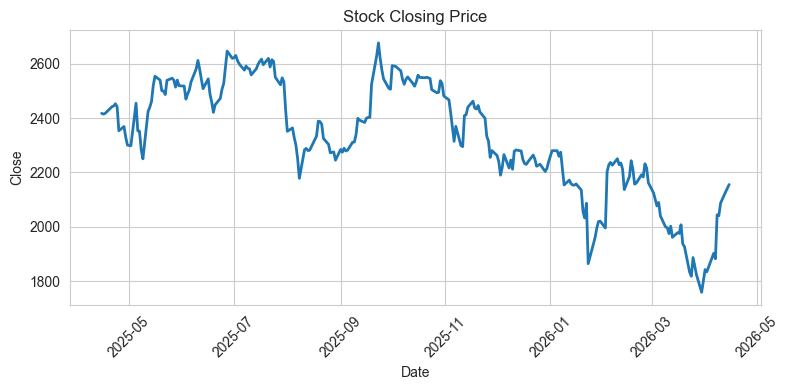

In [10]:
sns.set_style("whitegrid")

plt.figure(figsize=(8,4))
sns.lineplot(data=df['Close'], linewidth=2)

plt.title('Stock Closing Price')
plt.xticks(rotation=45)

plt.tight_layout()

### Histogram

This visualization helps analyze histogram of stock data.

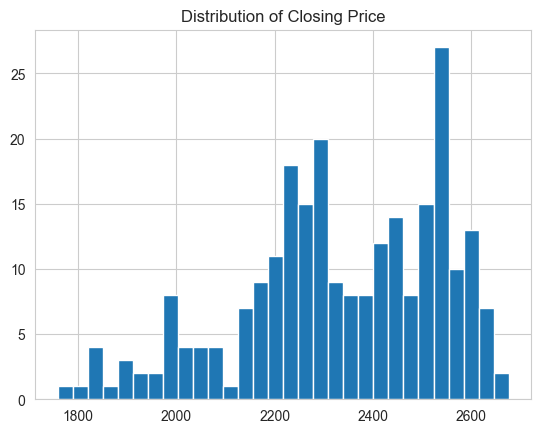

In [11]:
plt.figure()
plt.hist(df['Close'], bins=30)
plt.title('Distribution of Closing Price')
plt.show()

### Scatter Plot

This visualization helps analyze scatter plot of stock data.

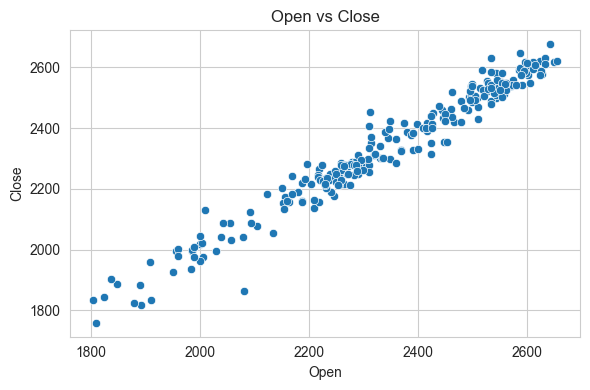

In [12]:
sns.set_style("whitegrid")
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['Open'],y=df['Close'])
plt.title('Open vs Close')
plt.tight_layout()
plt.show()

### Bar Chart

This visualization helps analyze bar chart of stock data.

Text(0.5, 0, 'Change % Range')

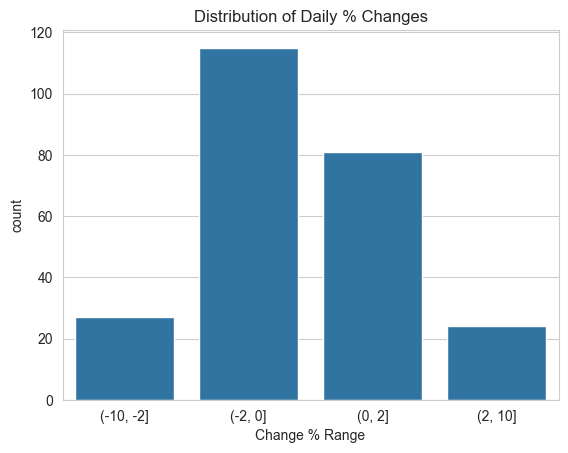

In [13]:
sns.set_style("whitegrid")

df['Cg%'] = ((df['Close'] - df['Open']) / df['Open']) * 100
sns.countplot(x=pd.cut(df['Cg%'], bins=[-10,-2,0,2,10]))
plt.title('Distribution of Daily % Changes')
plt.xlabel('Change % Range')

### Pie Chart

This visualization helps analyze pie chart of stock data.

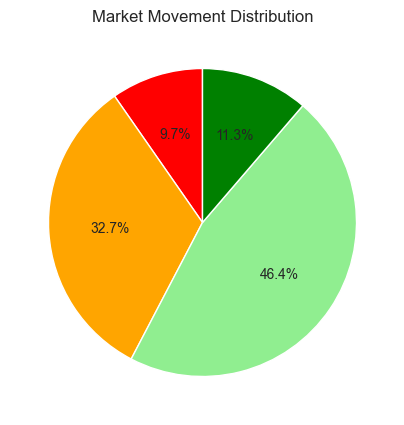

In [14]:
plt.figure(figsize=(5,5))
change = ((df['Close'] - df['Open']) / df['Open']) * 100
sizes = [(change > 2).sum(),((change > 0) & (change <= 2)).sum(),((change <= 0) & (change > -2)).sum(),(change <= -2).sum()]
plt.pie(sizes,autopct='%1.1f%%',startangle=90,colors=['red','orange','lightgreen','green'])
plt.title('Market Movement Distribution')
plt.show()

### Box Plot

This visualization helps analyze box plot of stock data.

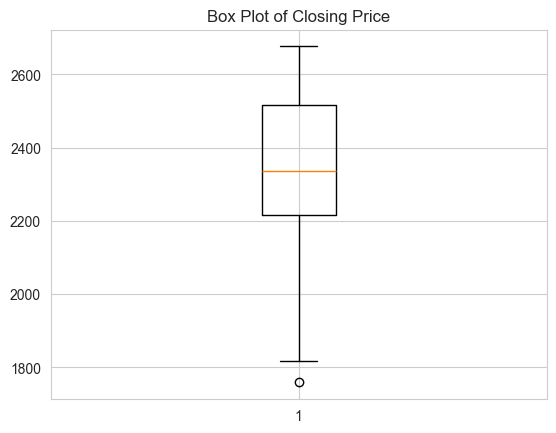

In [15]:
plt.figure()
plt.boxplot(df['Close'])
plt.title('Box Plot of Closing Price')
plt.show()

### Heatmap

This visualization helps analyze heatmap of stock data.

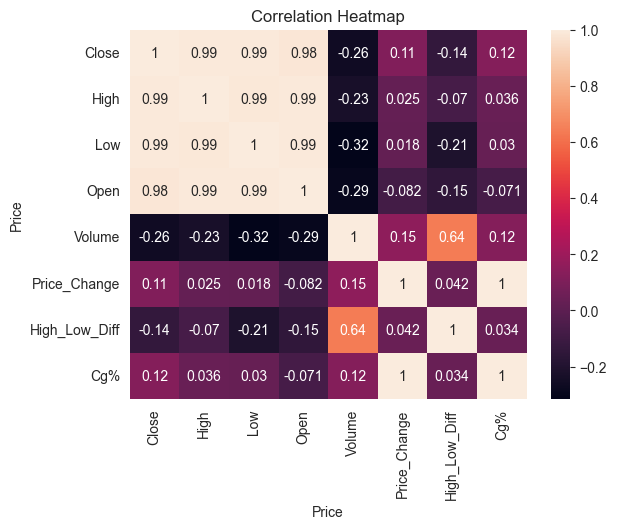

In [16]:
plt.figure()
sns.heatmap(df.corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()

### Pair Plot

This visualization helps analyze pair plot of stock data.

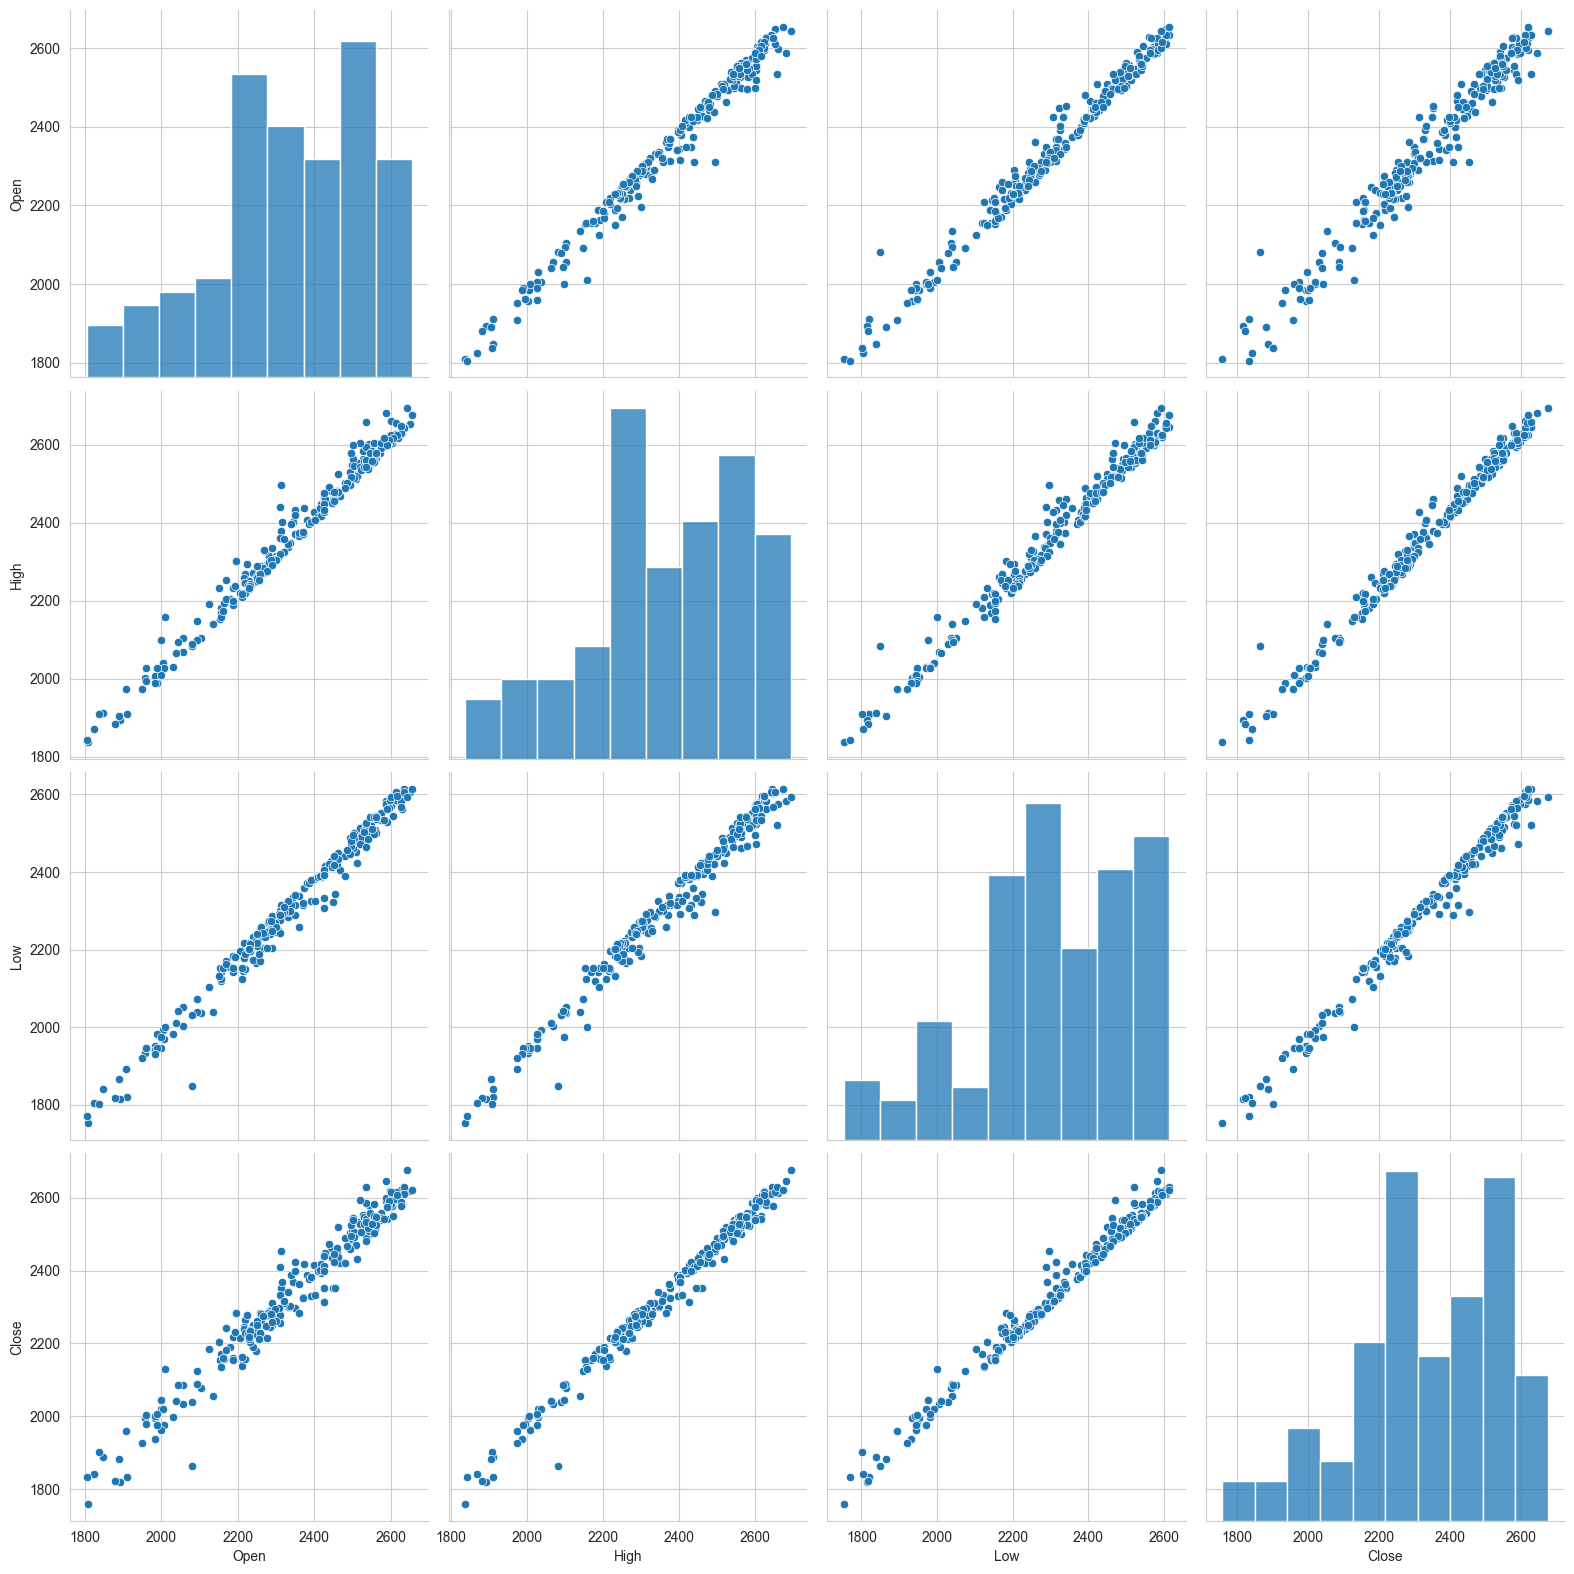

In [17]:
sns.pairplot(df[['Open', 'High', 'Low', 'Close']],height=4)
plt.show()

##  6. Statistical Testing (t-test)

Compare closing prices of up days vs down days.

In [18]:
up_days = df[df['Close'] > df['Open']]['Close']
down_days = df[df['Close'] <= df['Open']]['Close']

t_stat, p_value = stats.ttest_ind(up_days, down_days)

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Statistically significant difference")
else:
    print("No significant difference")

T-statistic: -0.5171694631206963
P-value: 0.6055025490356936
No significant difference


## 8. Outlier Detection
This section identifies and visualizes outliers in the dataset using the IQR (Interquartile Range) method.

Outlier count per column:

Close: 1
High: 0
Low: 0
Open: 0
Volume: 17
Price_Change: 8
High_Low_Diff: 8
Cg%: 7


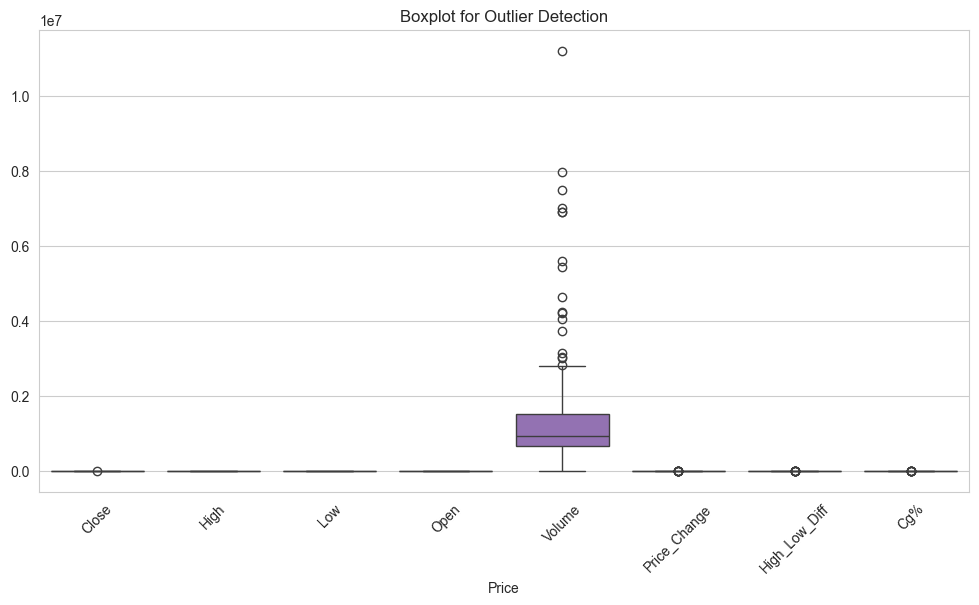

In [19]:
numeric_cols = df.select_dtypes(include=np.number).columns

print("Outlier count per column:\n")

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{col}: {len(outliers)}")
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)
plt.title("Boxplot for Outlier Detection")
plt.show()

##  7. Model Building

Train a Linear Regression model to predict closing prices.

In [20]:
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Close']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


##  8. Model Evaluation

Evaluate model performance using MAE and R² score.

In [21]:
y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 11.327573820552997
R2 Score: 0.9951263710984621


##  9. Prediction Visualization

Compare actual vs predicted values.

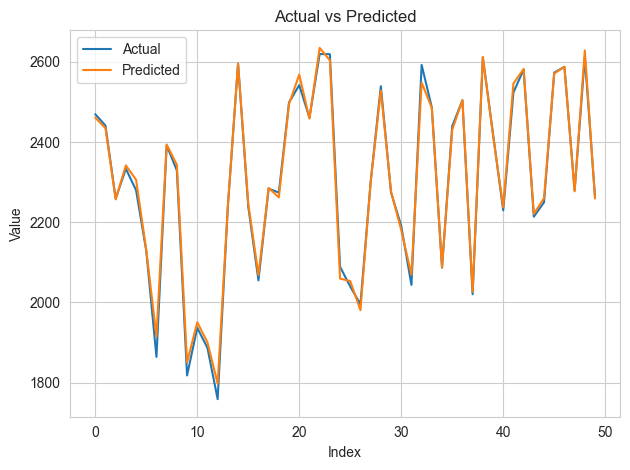

In [24]:
plt.figure()

plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')

plt.title('Actual vs Predicted')
plt.xlabel('Index')
plt.ylabel('Value')

plt.legend()
plt.tight_layout()